# Training Results Analysis

## Setup and Imports


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

from src.config import settings
from src.experiments.training.data import (
    load_variant_dataset,
    prepare_training_matrices,
)
from src.experiments.training.enums import ModelFamily
from src.experiments.training.models import build_model_spec
from src.experiments.training.splitters import build_cv_splits
from src.utils.analysis import (
    configure_notebook_plots,
    load_training_run_artifacts,
    select_training_run_dir,
)

In [2]:
configure_notebook_plots(figsize=(9, 6), use_whitegrid=True)

### Root output directories


In [3]:
artifacts_dir = Path("artifacts")

results_root = artifacts_dir / "training_results"

## 1. Run discovery and selection


In [4]:
run_id: str | None = None  # if run_id is not specified, last run id will be used

In [5]:
training_root = Path("../logs/training")
selected_run_dir, run_dirs = select_training_run_dir(training_root, run_id)

print(f"Selected run: {selected_run_dir.name}")
print(f"Available runs: {len(run_dirs)}")

Selected run: 20260413_155156
Available runs: 5


## 2. Data loading and validation


In [6]:
cv_summary, run_config, _, _ = load_training_run_artifacts(
    selected_run_dir,
    fallback_refit_metric=settings.training_gridsearch_refit_metric,
)

print("Run metadata:")
print(f"  Run_id: {selected_run_dir.name}")
print(f"  Dataset_version: {run_config.get('dataset_version', 'unknown')}")
print(f"  Git_commit: {str(run_config.get('git_commit', 'unknown'))[:8]}")
print(f"  Variants: {len(run_config.get('variants', []))}")
print(f"  CV_folds: {run_config.get('cv_folds', 'unknown')}")

dataset_version = str(run_config.get("dataset_version", "unknown")).replace("/", "-")
analysis_version = f"{selected_run_dir.name}_v{dataset_version}"
results_dir = results_root / analysis_version
results_dir.mkdir(parents=True, exist_ok=True)

Run metadata:
  Run_id: 20260413_155156
  Dataset_version: 1.0.1
  Git_commit: 1aa5cc1f
  Variants: 5
  CV_folds: 10


## 3. Metric overview


In [7]:
def format_mean_std_pairs(
    df: pd.DataFrame, mean_cols: list[str] | None = None, precision: int = 3
) -> pd.DataFrame:
    """Combine mean and std columns into a single formatted string column."""
    out = df.copy()

    if mean_cols is None:
        mean_cols = [c for c in out.columns if c.endswith("_mean")]

    for mean_col in mean_cols:
        base = mean_col.replace("_mean", "")
        std_col = f"{base}_std"

        if std_col not in out.columns:
            continue

        out[base] = (
            out[mean_col].round(precision).astype(str)
            + " ± "
            + out[std_col].round(precision).astype(str)
        )

        out.loc[out[mean_col].isna() | out[std_col].isna(), base] = None
        out = out.drop(columns=[mean_col, std_col])

    return out


format_mean_std_pairs(cv_summary.head())

,variant,model_family,best_params_json,n_candidates_tested,combination_counts_json,fit_elapsed_seconds,accuracy,balanced_accuracy,precision_macro,precision_micro,precision_weighted,recall_macro,recall_micro,recall_weighted,f1_macro,f1_micro,f1_weighted
0,corr_060,gradient_boosting,"{""model__criterion"": ""friedman_mse"", ""model__l...",144,"{""000"": 193, ""001"": 165, ""010"": 60, ""011"": 116...",684.566216,0.513 ± 0.029,0.326 ± 0.032,0.377 ± 0.07,0.513 ± 0.029,0.477 ± 0.04,0.326 ± 0.032,0.513 ± 0.029,0.513 ± 0.029,0.322 ± 0.033,0.513 ± 0.029,0.476 ± 0.028
1,corr_060,random_forest,"{""model__max_depth"": 30, ""model__max_features""...",72,"{""000"": 193, ""001"": 165, ""010"": 60, ""011"": 116...",82.832541,0.515 ± 0.035,0.311 ± 0.034,0.345 ± 0.079,0.515 ± 0.035,0.467 ± 0.048,0.311 ± 0.034,0.515 ± 0.035,0.515 ± 0.035,0.301 ± 0.045,0.515 ± 0.035,0.47 ± 0.037
2,corr_060,decision_tree,"{""model__criterion"": ""entropy"", ""model__max_de...",54,"{""000"": 193, ""001"": 165, ""010"": 60, ""011"": 116...",4.605237,0.478 ± 0.028,0.305 ± 0.045,0.308 ± 0.08,0.478 ± 0.028,0.432 ± 0.04,0.305 ± 0.045,0.478 ± 0.028,0.478 ± 0.028,0.295 ± 0.055,0.478 ± 0.028,0.447 ± 0.031
3,corr_060,neural_network,"{""model__batch_size"": 64, ""model__epochs"": 250...",36,"{""000"": 193, ""001"": 165, ""010"": 60, ""011"": 116...",450.552248,0.439 ± 0.036,0.262 ± 0.035,0.297 ± 0.099,0.439 ± 0.036,0.41 ± 0.051,0.262 ± 0.035,0.439 ± 0.036,0.439 ± 0.036,0.256 ± 0.044,0.439 ± 0.036,0.409 ± 0.035
4,corr_060,svm,"{""model__C"": 5.0, ""model__gamma"": ""scale"", ""mo...",20,"{""000"": 193, ""001"": 165, ""010"": 60, ""011"": 116...",18.830660,0.439 ± 0.028,0.248 ± 0.022,0.233 ± 0.054,0.439 ± 0.028,0.375 ± 0.045,0.248 ± 0.022,0.439 ± 0.028,0.439 ± 0.028,0.218 ± 0.026,0.439 ± 0.028,0.384 ± 0.029


## 4. Best model per variant


In [8]:
refit_metric = run_config["settings"]["training_gridsearch_refit_metric"]
refit_col = f"{refit_metric}_mean"

if refit_col not in cv_summary.columns:
    raise ValueError(f"Refit metric column not found in cv_summary: {refit_col}")

best_per_variant = (
    cv_summary.sort_values(["variant", refit_col], ascending=[True, False])
    .groupby("variant", as_index=False)
    .head(1)
    .reset_index(drop=True)
)
best_export_path = results_dir / f"best_per_variant_{analysis_version}.csv"
best_per_variant.to_csv(best_export_path, index=False)
print(f"Saved: {best_export_path}")

best_per_variant_table = best_per_variant[
    [
        "variant",
        "model_family",
        refit_col,
        f"{refit_metric}_std",
        "n_candidates_tested",
    ]
]

format_mean_std_pairs(best_per_variant_table, mean_cols=[refit_col])

Saved: artifacts/training_results/20260413_155156_v1.0.1/best_per_variant_20260413_155156_v1.0.1.csv


,variant,model_family,n_candidates_tested,f1_weighted
0,corr_060,gradient_boosting,144,0.476 ± 0.028
1,corr_070,gradient_boosting,144,0.478 ± 0.034
2,dom_080,gradient_boosting,144,0.473 ± 0.029
3,manual_selection,gradient_boosting,144,0.48 ± 0.038
4,original,gradient_boosting,144,0.476 ± 0.037


## 5. Heatmap of refit metric


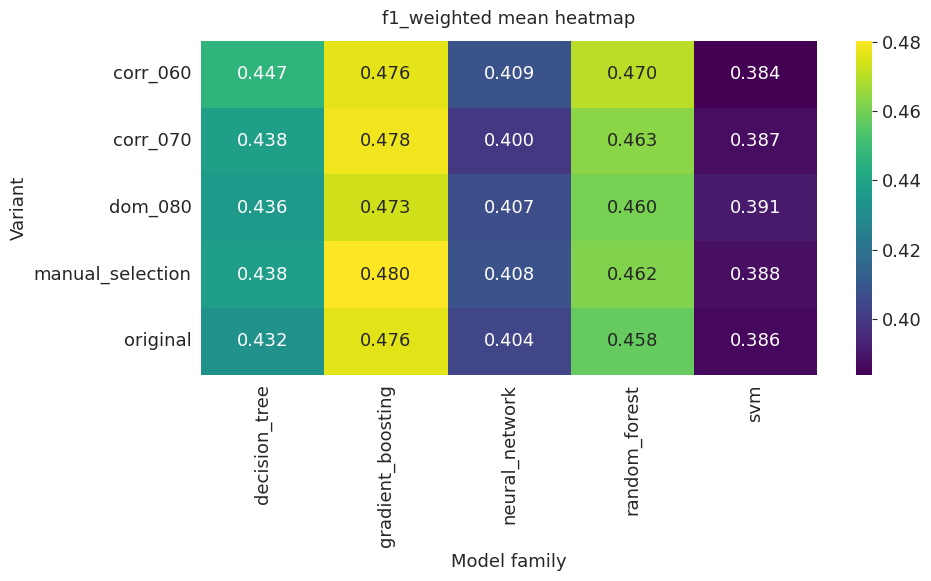

Saved: artifacts/training_results/20260413_155156_v1.0.1/heatmap_f1_weighted_mean_20260413_155156_v1.0.1.pdf


In [9]:
heatmap_data = cv_summary.pivot(
    index="variant", columns="model_family", values=refit_col
)
heatmap_path = results_dir / f"heatmap_{refit_metric}_mean_{analysis_version}.pdf"

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set_title(f"{refit_metric} mean heatmap", fontsize=13, pad=12)
ax.set_xlabel("Model family")
ax.set_ylabel("Variant")
plt.tight_layout()
plt.savefig(heatmap_path)
plt.show()

print(f"Saved: {heatmap_path}")

## 6. Error-bar comparison across dataset variants

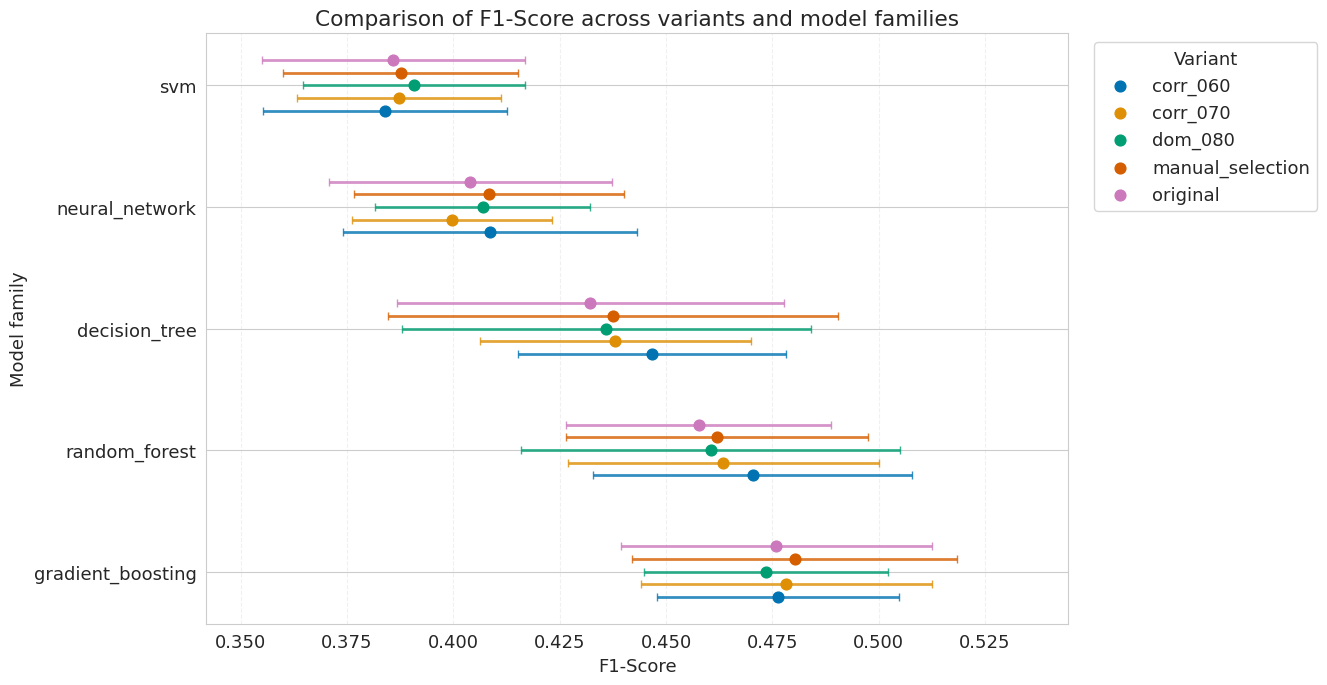

Saved: artifacts/training_results/20260413_155156_v1.0.1/models_f1_weighted_dotwhisker_merged_variants_20260413_155156_v1.0.1.pdf
Saved: artifacts/training_results/20260413_155156_v1.0.1/models_f1_weighted_dotwhisker_merged_table_20260413_155156_v1.0.1.csv


variant,model_family,corr_060,corr_070,dom_080,manual_selection,original
0,gradient_boosting,0.476 ± 0.028,0.478 ± 0.034,0.473 ± 0.029,0.480 ± 0.038,0.476 ± 0.037
1,random_forest,0.470 ± 0.037,0.463 ± 0.037,0.460 ± 0.045,0.462 ± 0.036,0.458 ± 0.031
2,decision_tree,0.447 ± 0.031,0.438 ± 0.032,0.436 ± 0.048,0.438 ± 0.053,0.432 ± 0.045
3,neural_network,0.409 ± 0.035,0.400 ± 0.023,0.407 ± 0.025,0.408 ± 0.032,0.404 ± 0.033
4,svm,0.384 ± 0.029,0.387 ± 0.024,0.391 ± 0.026,0.388 ± 0.028,0.386 ± 0.031


In [10]:
# 1) Prepare data used for plotting.
std_col = f"{refit_metric}_std"
plot_df = cv_summary[["variant", "model_family", refit_col, std_col]].copy()
plot_df[refit_col] = pd.to_numeric(plot_df[refit_col], errors="coerce")
plot_df[std_col] = pd.to_numeric(plot_df[std_col], errors="coerce")

# 2) Decide row and legend order.
variant_order = sorted(plot_df["variant"].dropna().unique())
if not variant_order:
    raise ValueError("No variant data available.")

baseline_df = plot_df[plot_df["variant"] == "original"].copy()
baseline_df = baseline_df.dropna(subset=["model_family", refit_col])
baseline_df = baseline_df.sort_values(refit_col, ascending=False)
baseline_models = baseline_df["model_family"].drop_duplicates().tolist()

all_models = sorted(plot_df["model_family"].dropna().unique())
model_order = baseline_models.copy()
for model_name in all_models:
    if model_name not in model_order:
        model_order.append(model_name)

if not model_order:
    raise ValueError("No model-family data available.")

# 3) Configure plot layout.
y_base = np.arange(len(model_order), dtype=float) * 1.25
if len(variant_order) > 1:
    offsets = np.linspace(-0.26, 0.26, len(variant_order))
else:
    offsets = np.array([0.0])

palette = sns.color_palette("colorblind", n_colors=len(variant_order))
variant_colors = {}
for idx, variant in enumerate(variant_order):
    variant_colors[variant] = palette[idx]

fig, ax = plt.subplots(figsize=(13.5, max(6.0, 0.85 * len(model_order) + 2.8)))

# 4) Plot each variant.
for idx, variant in enumerate(variant_order):
    variant_rows = plot_df[plot_df["variant"] == variant].copy()
    variant_rows = variant_rows.set_index("model_family").reindex(model_order)

    means = variant_rows[refit_col].to_numpy(dtype=float)
    stds = variant_rows[std_col].fillna(0.0).to_numpy(dtype=float)
    y_values = y_base + offsets[idx]
    valid = ~np.isnan(means)

    ax.errorbar(
        means[valid],
        y_values[valid],
        xerr=stds[valid],
        fmt="none",
        ecolor=variant_colors[variant],
        elinewidth=2,
        capsize=3,
        alpha=0.8,
    )
    ax.scatter(
        means[valid],
        y_values[valid],
        color=variant_colors[variant],
        s=60,
        label=variant,
    )

ax.set_yticks(y_base)
ax.set_yticklabels(model_order)
ax.set_xlabel("F1-Score")
ax.set_ylabel("Model family")
ax.set_title("Comparison of F1-Score across variants and model families")

valid_means = plot_df[refit_col].notna()
if valid_means.any():
    low_values = plot_df.loc[valid_means, refit_col] - plot_df.loc[
        valid_means, std_col
    ].fillna(0.0)
    high_values = plot_df.loc[valid_means, refit_col] + plot_df.loc[
        valid_means, std_col
    ].fillna(0.0)
    low = float(low_values.min())
    high = float(high_values.max())
    span = max(1e-6, high - low)
    ax.set_xlim(low - 0.08 * span, high + 0.16 * span)

ax.grid(axis="x", linestyle="--", alpha=0.28)
ax.legend(title="Variant", loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=True)

plt.tight_layout()
merged_plot_path = (
    results_dir
    / f"models_{refit_metric}_dotwhisker_merged_variants_{analysis_version}.pdf"
)
plt.savefig(merged_plot_path)
plt.show()
print(f"Saved: {merged_plot_path}")

# 5) Export summary table (mean ± std).
summary_table = plot_df.copy()
mean_sd_col = f"{refit_metric}_mean_sd"

summary_table[mean_sd_col] = summary_table.apply(
    lambda row: (
        f"{row[refit_col]:.3f} ± {row[std_col]:.3f}"
        if pd.notna(row[refit_col]) and pd.notna(row[std_col])
        else None
    ),
    axis=1,
)

summary_table_pivot = summary_table.pivot(
    index="model_family",
    columns="variant",
    values=mean_sd_col,
)
summary_table_pivot = summary_table_pivot.reindex(model_order)
summary_table_pivot = summary_table_pivot.reindex(columns=variant_order)
summary_table_pivot = summary_table_pivot.reset_index()

summary_table_path = (
    results_dir
    / f"models_{refit_metric}_dotwhisker_merged_table_{analysis_version}.csv"
)
summary_table_pivot.to_csv(summary_table_path, index=False)
print(f"Saved: {summary_table_path}")
display(summary_table_pivot)

## 7. Hyperparameter comparison


In [11]:
params_rows = []
for row in cv_summary.itertuples(index=False):
    params = {}

    if not pd.isna(row.best_params_json):
        params = json.loads(row.best_params_json)

    params_rows.append(
        {
            "variant": row.variant,
            "model_family": row.model_family,
            "n_candidates_tested": row.n_candidates_tested,
            **params,
        }
    )

best_params_table = pd.DataFrame(params_rows)
params_export_path = results_dir / f"best_params_expanded_{analysis_version}.csv"
best_params_table.to_csv(params_export_path, index=False)
print(f"Saved: {params_export_path}")

best_params_table

Saved: artifacts/training_results/20260413_155156_v1.0.1/best_params_expanded_20260413_155156_v1.0.1.csv


,variant,model_family,n_candidates_tested,model__criterion,model__learning_rate,model__max_depth,model__min_samples_leaf,model__n_estimators,model__subsample,model__max_features,model__min_samples_split,model__batch_size,model__epochs,model__hidden_activation,model__hidden_layer_sizes,model__l2_alpha,model__optimizer_name,model__C,model__gamma,model__kernel
0,corr_060,gradient_boosting,144,friedman_mse,0.0300,3.0,2.0,100.0,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,corr_060,random_forest,72,NaN,NaN,30.0,1.0,200.0,NaN,sqrt,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,corr_060,decision_tree,54,entropy,NaN,5.0,1.0,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,corr_060,neural_network,36,NaN,0.0007,NaN,NaN,NaN,NaN,NaN,NaN,64.0,250.0,relu,[54],0.0010,adam,NaN,NaN,NaN
4,corr_060,svm,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,scale,linear
5,corr_070,gradient_boosting,144,friedman_mse,0.1000,3.0,2.0,50.0,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,corr_070,random_forest,72,NaN,NaN,30.0,1.0,100.0,NaN,sqrt,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,corr_070,decision_tree,54,entropy,NaN,5.0,1.0,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,corr_070,neural_network,36,NaN,0.0007,NaN,NaN,NaN,NaN,NaN,NaN,64.0,250.0,relu,[35],0.0010,adam,NaN,NaN,NaN
9,corr_070,svm,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,scale,rbf


## 8. Export compact summary


In [12]:
summary_export_cols = [
    "variant",
    "model_family",
    refit_col,
    f"{refit_metric}_std",
    "n_candidates_tested",
    "best_params_json",
]
summary_export = cv_summary[summary_export_cols].sort_values(
    ["variant", refit_col], ascending=[True, False]
)
summary_export_path = results_dir / f"cv_summary_compact_{analysis_version}.csv"
summary_export.to_csv(summary_export_path, index=False)
print(f"Saved: {summary_export_path}")

format_mean_std_pairs(summary_export, mean_cols=[refit_col])

Saved: artifacts/training_results/20260413_155156_v1.0.1/cv_summary_compact_20260413_155156_v1.0.1.csv


,variant,model_family,n_candidates_tested,best_params_json,f1_weighted
0,corr_060,gradient_boosting,144,"{""model__criterion"": ""friedman_mse"", ""model__l...",0.476 ± 0.028
1,corr_060,random_forest,72,"{""model__max_depth"": 30, ""model__max_features""...",0.47 ± 0.037
2,corr_060,decision_tree,54,"{""model__criterion"": ""entropy"", ""model__max_de...",0.447 ± 0.031
3,corr_060,neural_network,36,"{""model__batch_size"": 64, ""model__epochs"": 250...",0.409 ± 0.035
4,corr_060,svm,20,"{""model__C"": 5.0, ""model__gamma"": ""scale"", ""mo...",0.384 ± 0.029
5,corr_070,gradient_boosting,144,"{""model__criterion"": ""friedman_mse"", ""model__l...",0.478 ± 0.034
6,corr_070,random_forest,72,"{""model__max_depth"": 30, ""model__max_features""...",0.463 ± 0.037
7,corr_070,decision_tree,54,"{""model__criterion"": ""entropy"", ""model__max_de...",0.438 ± 0.032
8,corr_070,neural_network,36,"{""model__batch_size"": 64, ""model__epochs"": 250...",0.4 ± 0.023
9,corr_070,svm,20,"{""model__C"": 5.0, ""model__gamma"": ""scale"", ""mo...",0.387 ± 0.024


## 9. Training-time comparison across variants and models


In [13]:
def format_duration(seconds: float) -> str | None:
    """Convert seconds to a human-readable string format."""
    if pd.isna(seconds):
        return None
    total_seconds = round(float(seconds))
    minutes, secs = divmod(total_seconds, 60)
    return f"{minutes} min {secs} sec"

Saved: artifacts/training_results/20260413_155156_v1.0.1/training_time_comparison_20260413_155156_v1.0.1.pdf


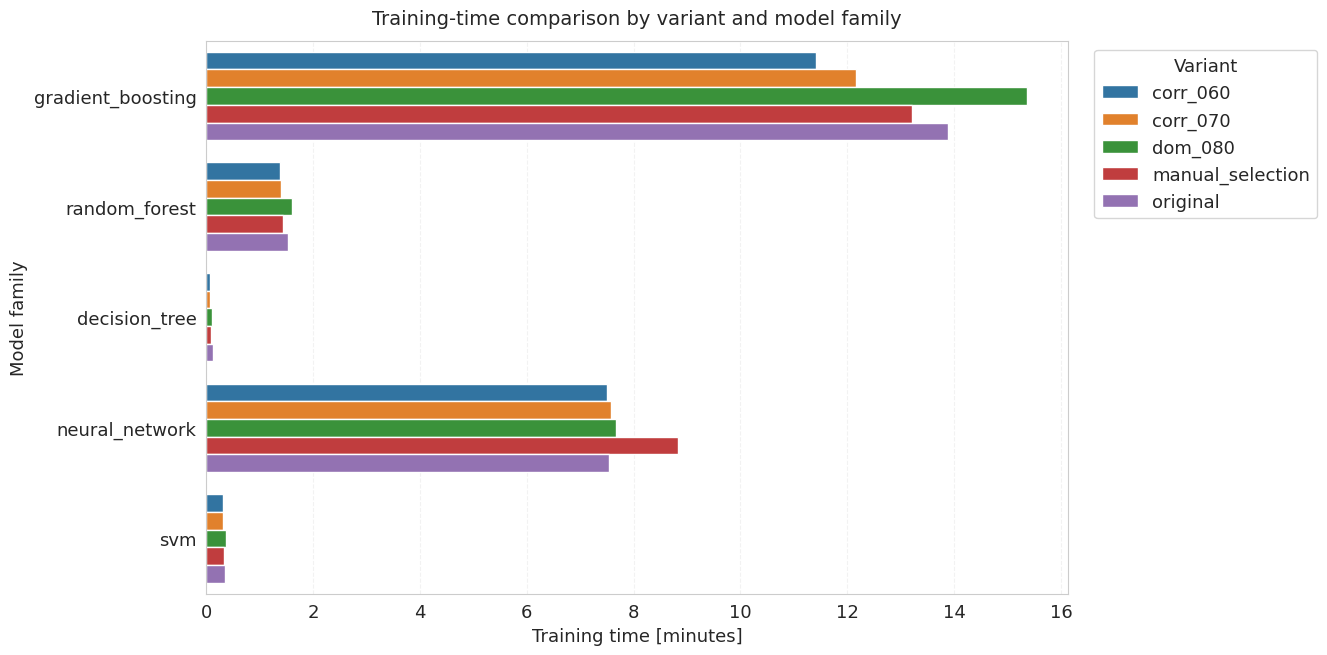

Saved: artifacts/training_results/20260413_155156_v1.0.1/training_time_table_20260413_155156_v1.0.1.csv


model_family,gradient_boosting,random_forest,decision_tree,neural_network,svm
variant,,,,,
corr_060,11 min 25 sec,1 min 23 sec,0 min 5 sec,7 min 31 sec,0 min 19 sec
corr_070,12 min 10 sec,1 min 24 sec,0 min 5 sec,7 min 34 sec,0 min 19 sec
dom_080,15 min 22 sec,1 min 36 sec,0 min 6 sec,7 min 40 sec,0 min 23 sec
manual_selection,13 min 13 sec,1 min 26 sec,0 min 5 sec,8 min 50 sec,0 min 20 sec
original,13 min 53 sec,1 min 32 sec,0 min 8 sec,7 min 32 sec,0 min 21 sec


In [14]:
timing_summary_path = selected_run_dir / "timing_summary.csv"
if not timing_summary_path.exists():
    raise FileNotFoundError(f"Missing timing_summary.csv: {timing_summary_path}")

timing_summary = pd.read_csv(timing_summary_path)
timing_model = timing_summary[timing_summary["scope"] == "model"].copy()

timing_model["elapsed_seconds"] = pd.to_numeric(
    timing_model["elapsed_seconds"], errors="coerce"
)
timing_model = timing_model.dropna(subset=["elapsed_seconds"])
timing_model["elapsed_minutes"] = timing_model["elapsed_seconds"] / 60.0

variant_order_time = sorted(timing_model["variant"].dropna().unique())
model_order_time = [
    model for model in model_order if model in set(timing_model["model_family"])
]
model_order_time += [
    model
    for model in sorted(timing_model["model_family"].dropna().unique())
    if model not in model_order_time
]

timing_model["model_family"] = pd.Categorical(
    timing_model["model_family"], categories=model_order_time, ordered=True
)

fig, ax = plt.subplots(figsize=(13.5, max(6.0, 0.85 * len(model_order_time) + 2.5)))
sns.barplot(
    data=timing_model,
    x="elapsed_minutes",
    y="model_family",
    hue="variant",
    order=model_order_time,
    hue_order=variant_order_time,
    ax=ax,
)
ax.set_xlabel("Training time [minutes]")
ax.set_ylabel("Model family")
ax.set_title(
    "Training-time comparison by variant and model family", fontsize=14, pad=12
)
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.legend(title="Variant", loc="upper left", bbox_to_anchor=(1.02, 1.00), frameon=True)
plt.tight_layout()

timing_plot_export = results_dir / f"training_time_comparison_{analysis_version}.pdf"
plt.savefig(timing_plot_export)
print(f"Saved: {timing_plot_export}")
plt.show()


timing_by_variant_model = timing_model.groupby(
    ["variant", "model_family"], as_index=False, observed=True
)["elapsed_seconds"].sum()

timing_by_variant_model["time"] = timing_by_variant_model["elapsed_seconds"].apply(
    format_duration
)

timing_matrix = timing_by_variant_model.pivot(
    index="variant", columns="model_family", values="time"
).reindex(index=variant_order_time, columns=model_order_time)

timing_table_export = results_dir / f"training_time_table_{analysis_version}.csv"
timing_matrix.to_csv(timing_table_export, index=True)
print(f"Saved: {timing_table_export}")

timing_matrix

## 10. Gradient Boosting comparison by n_estimators and criterion


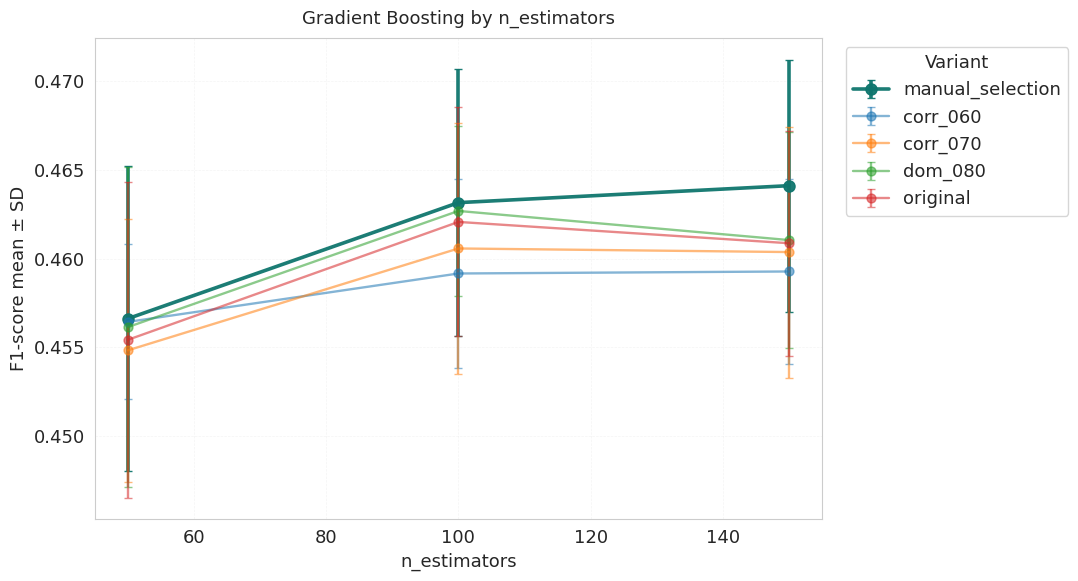

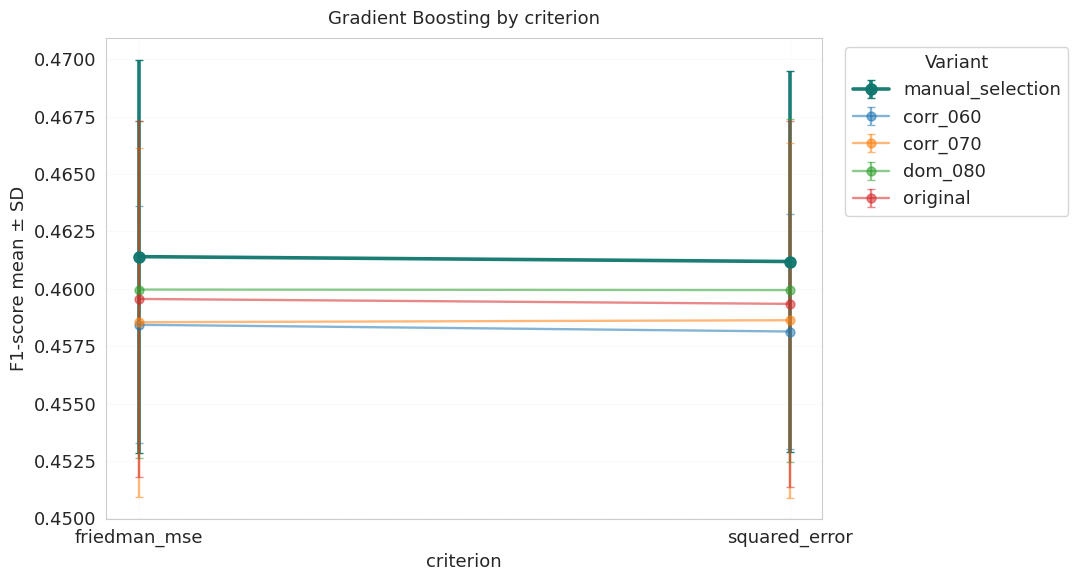

Saved: artifacts/training_results/20260413_155156_v1.0.1/gb_n_estimators_independent_table_20260413_155156_v1.0.1.csv
Saved: artifacts/training_results/20260413_155156_v1.0.1/gb_n_estimators_independent_plot_20260413_155156_v1.0.1.pdf
Saved: artifacts/training_results/20260413_155156_v1.0.1/gb_criterion_independent_table_20260413_155156_v1.0.1.csv
Saved: artifacts/training_results/20260413_155156_v1.0.1/gb_criterion_independent_plot_20260413_155156_v1.0.1.pdf
Saved: artifacts/training_results/20260413_155156_v1.0.1/gb_hyperparameter_impact_20260413_155156_v1.0.1.csv


,variant,model_family,n_estimators,f1_score,score_mean,score_sd,candidates
0,corr_060,gradient_boosting,50,0.4564 ± 0.0044,0.456426,0.004376,48
1,corr_060,gradient_boosting,100,0.4592 ± 0.0053,0.459158,0.005305,48
2,corr_060,gradient_boosting,150,0.4593 ± 0.0052,0.459271,0.005226,48
3,corr_070,gradient_boosting,50,0.4548 ± 0.0074,0.454821,0.007435,48
4,corr_070,gradient_boosting,100,0.4606 ± 0.0071,0.460570,0.007075,48
5,corr_070,gradient_boosting,150,0.4604 ± 0.0071,0.460367,0.007080,48
6,dom_080,gradient_boosting,50,0.4561 ± 0.0090,0.456132,0.009011,48
7,dom_080,gradient_boosting,100,0.4627 ± 0.0048,0.462687,0.004808,48
8,dom_080,gradient_boosting,150,0.4610 ± 0.0061,0.461044,0.006091,48
9,manual_selection,gradient_boosting,50,0.4566 ± 0.0086,0.456610,0.008607,48


,variant,model_family,criterion,f1_score,score_mean,score_sd,candidates
0,corr_060,gradient_boosting,friedman_mse,0.4584 ± 0.0052,0.458432,0.005159,72
1,corr_060,gradient_boosting,squared_error,0.4581 ± 0.0051,0.458139,0.005122,72
2,corr_070,gradient_boosting,friedman_mse,0.4585 ± 0.0076,0.458543,0.007594,72
3,corr_070,gradient_boosting,squared_error,0.4586 ± 0.0077,0.458629,0.007722,72
4,dom_080,gradient_boosting,friedman_mse,0.4600 ± 0.0073,0.459965,0.007318,72
5,dom_080,gradient_boosting,squared_error,0.4599 ± 0.0075,0.459944,0.007468,72
6,manual_selection,gradient_boosting,friedman_mse,0.4614 ± 0.0086,0.461399,0.008572,72
7,manual_selection,gradient_boosting,squared_error,0.4612 ± 0.0083,0.461186,0.008315,72
8,original,gradient_boosting,friedman_mse,0.4596 ± 0.0077,0.459556,0.007750,72
9,original,gradient_boosting,squared_error,0.4593 ± 0.0080,0.459342,0.007982,72


In [15]:
def _extract_gb_params(params_json: str) -> pd.Series:
    params = (
        json.loads(params_json)
        if isinstance(params_json, str) and params_json.strip()
        else {}
    )
    return pd.Series(
        {
            "n_estimators": params.get("model__n_estimators"),
            "criterion": params.get("model__criterion"),
        }
    )


def _compute_stats(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    stats = df.groupby(group_cols, as_index=False)[refit_col].agg(
        score_mean="mean", score_sd="std", n="count"
    )
    stats["score_sd"] = stats["score_sd"].fillna(0.0)
    return stats


def _build_result_table(stats_df: pd.DataFrame, key_col: str) -> pd.DataFrame:
    table = stats_df.copy()
    table["model_family"] = "gradient_boosting"
    table["f1_score"] = [
        f"{mean:.4f} ± {sd:.4f}"
        for mean, sd in zip(table["score_mean"], table["score_sd"], strict=False)
    ]
    return table[
        [
            "variant",
            "model_family",
            key_col,
            "f1_score",
            "score_mean",
            "score_sd",
            "n",
        ]
    ].rename(columns={"n": "candidates"})


def _plot_by_variant(
    stats_df: pd.DataFrame,
    *,
    x_col: str,
    x_label: str,
    title: str,
    export_path: Path,
    variant_order: list[str],
    xticks: list[int] | None = None,
    xticklabels: list[str] | None = None,
) -> None:
    fig, ax = plt.subplots(figsize=(11.0, 6.0))

    for variant in variant_order:
        vdf = stats_df[stats_df["variant"] == variant].sort_values(x_col)
        if vdf.empty:
            continue

        is_manual = variant == "manual_selection"
        ax.errorbar(
            vdf[x_col],
            vdf["score_mean"],
            yerr=vdf["score_sd"],
            marker="o",
            markersize=8.0 if is_manual else 6.4,
            linewidth=2.6 if is_manual else 1.7,
            capsize=3.0,
            alpha=0.95 if is_manual else 0.55,
            color="#0f766e" if is_manual else None,
            label=variant,
        )

    if xticks is not None:
        ax.set_xticks(xticks)
    if xticklabels is not None:
        ax.set_xticklabels(xticklabels)

    ax.set_xlabel(x_label)
    ax.set_ylabel("F1-score mean ± SD")
    ax.set_title(title, fontsize=13, pad=10)
    ax.grid(axis="both", linestyle="--", linewidth=0.5, alpha=0.2)

    handles, labels = ax.get_legend_handles_labels()
    handle_by_label = {
        lab: handle for handle, lab in zip(handles, labels, strict=False)
    }
    ordered_labels = [
        variant for variant in variant_order if variant in handle_by_label
    ]
    ordered_handles = [handle_by_label[variant] for variant in ordered_labels]
    ax.legend(
        ordered_handles,
        ordered_labels,
        title="Variant",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        frameon=True,
    )

    plt.tight_layout()
    plt.savefig(export_path)
    plt.show()


# 1) Load files.
cv_candidates_path = selected_run_dir / "cv_candidates.csv"
hyperparameter_impact_path = selected_run_dir / "hyperparameter_impact.csv"

if not cv_candidates_path.exists():
    raise FileNotFoundError(f"Missing cv_candidates.csv: {cv_candidates_path}")
if not hyperparameter_impact_path.exists():
    raise FileNotFoundError(
        f"Missing hyperparameter_impact.csv: {hyperparameter_impact_path}"
    )

cv_candidates = pd.read_csv(cv_candidates_path)
hyperparameter_impact = pd.read_csv(hyperparameter_impact_path)

# 2) Keep only gradient boosting rows and extract tested params.
gb_candidates = cv_candidates[
    cv_candidates["model_family"] == "gradient_boosting"
].copy()
if gb_candidates.empty:
    raise ValueError("No gradient_boosting rows found in cv_candidates.csv")

gb_candidates[["n_estimators", "criterion"]] = gb_candidates["params_json"].apply(
    _extract_gb_params
)
gb_candidates["n_estimators"] = pd.to_numeric(
    gb_candidates["n_estimators"], errors="coerce"
)
gb_candidates = gb_candidates.dropna(subset=["n_estimators", "criterion", refit_col])
gb_candidates["n_estimators"] = gb_candidates["n_estimators"].astype(int)

# 3) Prepare independent summaries and export tables.
gb_by_n_stats = _compute_stats(gb_candidates, ["variant", "n_estimators"]).sort_values(
    ["variant", "n_estimators"]
)
gb_by_criterion_stats = _compute_stats(
    gb_candidates, ["variant", "criterion"]
).sort_values(["variant", "criterion"])

gb_by_n_table = _build_result_table(gb_by_n_stats, "n_estimators")
gb_by_criterion_table = _build_result_table(gb_by_criterion_stats, "criterion")

gb_by_n_export = (
    results_dir / f"gb_n_estimators_independent_table_{analysis_version}.csv"
)
gb_by_criterion_export = (
    results_dir / f"gb_criterion_independent_table_{analysis_version}.csv"
)
gb_by_n_table.to_csv(gb_by_n_export, index=False)
gb_by_criterion_table.to_csv(gb_by_criterion_export, index=False)

# 4) Build variant order (manual_selection first).
variant_order = sorted(gb_by_n_stats["variant"].dropna().unique())
if "manual_selection" in variant_order:
    variant_order = ["manual_selection"] + [
        v for v in variant_order if v != "manual_selection"
    ]

# 5) Plot n_estimators comparison.
gb_by_n_plot_export = (
    results_dir / f"gb_n_estimators_independent_plot_{analysis_version}.pdf"
)
_plot_by_variant(
    gb_by_n_stats,
    x_col="n_estimators",
    x_label="n_estimators",
    title="Gradient Boosting by n_estimators",
    export_path=gb_by_n_plot_export,
    variant_order=variant_order,
)

# 6) Plot criterion comparison.
criterion_order = sorted(gb_by_criterion_stats["criterion"].dropna().unique())
criterion_to_x = {criterion: i for i, criterion in enumerate(criterion_order)}
gb_by_criterion_plot_stats = gb_by_criterion_stats.copy()
gb_by_criterion_plot_stats["x"] = gb_by_criterion_plot_stats["criterion"].map(
    criterion_to_x
)

gb_by_criterion_plot_export = (
    results_dir / f"gb_criterion_independent_plot_{analysis_version}.pdf"
)
_plot_by_variant(
    gb_by_criterion_plot_stats,
    x_col="x",
    x_label="criterion",
    title="Gradient Boosting by criterion",
    export_path=gb_by_criterion_plot_export,
    variant_order=variant_order,
    xticks=list(range(len(criterion_order))),
    xticklabels=criterion_order,
)

# 7) Export matching hyperparameter impact subset.
gb_impact_filtered = hyperparameter_impact[
    (hyperparameter_impact["model_family"] == "gradient_boosting")
    & (
        hyperparameter_impact["param_name"].isin(
            ["model__n_estimators", "model__criterion"]
        )
    )
].copy()
gb_impact_export = results_dir / f"gb_hyperparameter_impact_{analysis_version}.csv"
gb_impact_filtered.to_csv(gb_impact_export, index=False)

print(f"Saved: {gb_by_n_export}")
print(f"Saved: {gb_by_n_plot_export}")
print(f"Saved: {gb_by_criterion_export}")
print(f"Saved: {gb_by_criterion_plot_export}")
print(f"Saved: {gb_impact_export}")

display(gb_by_n_table)
display(gb_by_criterion_table)

## 11. All training results master table


In [16]:
master_table = cv_summary.copy()

if not timing_model.empty:
    timing_join = timing_model[["variant", "model_family", "elapsed_seconds"]].copy()
    timing_join = timing_join.rename(
        columns={"elapsed_seconds": "training_time_seconds"}
    )
    master_table = master_table.merge(
        timing_join, on=["variant", "model_family"], how="left"
    )

formatted_master = format_mean_std_pairs(master_table)

timing_summary_table = formatted_master[
    [
        "variant",
        "model_family",
        "f1_weighted",
        "balanced_accuracy",
        "accuracy",
        "precision_weighted",
        "recall_weighted",
    ]
].rename(
    columns={
        "model_family": "model",
        "f1_weighted": "f1-score",
        "balanced_accuracy": "balanced acc",
        "precision_weighted": "precision",
        "recall_weighted": "recall",
    }
)

timing_summary_table = timing_summary_table.sort_values(
    ["variant", "model"]
).reset_index(drop=True)

master_export = results_dir / f"training_results_master_table_{analysis_version}.csv"
timing_summary_table.to_csv(master_export, index=False)
print(f"Saved: {master_export}")

timing_summary_table

Saved: artifacts/training_results/20260413_155156_v1.0.1/training_results_master_table_20260413_155156_v1.0.1.csv


,variant,model,f1-score,balanced acc,accuracy,precision,recall
0,corr_060,decision_tree,0.447 ± 0.031,0.305 ± 0.045,0.478 ± 0.028,0.432 ± 0.04,0.478 ± 0.028
1,corr_060,gradient_boosting,0.476 ± 0.028,0.326 ± 0.032,0.513 ± 0.029,0.477 ± 0.04,0.513 ± 0.029
2,corr_060,neural_network,0.409 ± 0.035,0.262 ± 0.035,0.439 ± 0.036,0.41 ± 0.051,0.439 ± 0.036
3,corr_060,random_forest,0.47 ± 0.037,0.311 ± 0.034,0.515 ± 0.035,0.467 ± 0.048,0.515 ± 0.035
4,corr_060,svm,0.384 ± 0.029,0.248 ± 0.022,0.439 ± 0.028,0.375 ± 0.045,0.439 ± 0.028
5,corr_070,decision_tree,0.438 ± 0.032,0.29 ± 0.032,0.474 ± 0.03,0.424 ± 0.037,0.474 ± 0.03
6,corr_070,gradient_boosting,0.478 ± 0.034,0.334 ± 0.034,0.509 ± 0.04,0.481 ± 0.034,0.509 ± 0.04
7,corr_070,neural_network,0.4 ± 0.023,0.259 ± 0.027,0.433 ± 0.026,0.4 ± 0.027,0.433 ± 0.026
8,corr_070,random_forest,0.463 ± 0.037,0.304 ± 0.031,0.509 ± 0.037,0.452 ± 0.041,0.509 ± 0.037
9,corr_070,svm,0.387 ± 0.024,0.248 ± 0.016,0.433 ± 0.026,0.399 ± 0.043,0.433 ± 0.026


## 12. Runtime vs. accuracy trade-off

In [17]:
# 1) Split timing data by scope.
model_timing = timing_summary[timing_summary["scope"] == "model"].copy()
variant_timing = timing_summary[timing_summary["scope"] == "variant"].copy()


def _add_mean_std_column(
    df: pd.DataFrame,
    output_col: str,
    mean_col: str,
    std_col: str,
    *,
    precision: int = 4,
) -> None:
    df[output_col] = [
        f"{mean_val:.{precision}f} ± {std_val:.{precision}f}"
        for mean_val, std_val in zip(df[mean_col], df[std_col], strict=False)
    ]


# 2) Load variant metadata (feature counts).
variant_overview_path = (
    Path("../data/processed")
    / f"v{dataset_version}"
    / "variants"
    / "variant_overview.csv"
)
print(f"Using variant overview: {variant_overview_path}")

variant_meta = pd.read_csv(variant_overview_path)[
    ["variant", "feature_count", "dropped_feature_count"]
].copy()

# 3) Table A: model runtime vs. accuracy (aggregated over variants).
model_tradeoff = cv_summary.merge(
    model_timing[["variant", "model_family", "elapsed_seconds"]],
    on=["variant", "model_family"],
    how="left",
)

model_summary = model_tradeoff.groupby("model_family", as_index=False).agg(
    avg_time_seconds=("elapsed_seconds", "mean"),
    avg_f1_mean=("f1_weighted_mean", "mean"),
    avg_f1_std=("f1_weighted_std", "mean"),
    avg_bal_acc_mean=("balanced_accuracy_mean", "mean"),
    avg_bal_acc_std=("balanced_accuracy_std", "mean"),
    avg_accuracy_mean=("accuracy_mean", "mean"),
    avg_accuracy_std=("accuracy_std", "mean"),
    candidates=("n_candidates_tested", "mean"),
)

best_idx = model_tradeoff.groupby("model_family")["f1_weighted_mean"].idxmax()
best_rows = model_tradeoff.loc[
    best_idx,
    [
        "model_family",
        "variant",
        "f1_weighted_mean",
        "f1_weighted_std",
        "elapsed_seconds",
    ],
].rename(
    columns={
        "variant": "best variant",
        "f1_weighted_mean": "best_f1_mean",
        "f1_weighted_std": "best_f1_std",
        "elapsed_seconds": "best_time_seconds",
    }
)

model_summary = model_summary.merge(best_rows, on="model_family", how="left")
model_summary["avg time"] = model_summary["avg_time_seconds"].map(format_duration)
model_summary["best time"] = model_summary["best_time_seconds"].map(format_duration)
model_summary["candidates"] = model_summary["candidates"].round().astype("Int64")

_add_mean_std_column(model_summary, "avg f1-score", "avg_f1_mean", "avg_f1_std")
_add_mean_std_column(
    model_summary,
    "avg balanced acc",
    "avg_bal_acc_mean",
    "avg_bal_acc_std",
)
_add_mean_std_column(
    model_summary, "avg accuracy", "avg_accuracy_mean", "avg_accuracy_std"
)
_add_mean_std_column(model_summary, "best f1-score", "best_f1_mean", "best_f1_std")

model_summary = model_summary.sort_values("avg_f1_mean", ascending=False).reset_index(
    drop=True
)
model_summary_table = model_summary[
    [
        "model_family",
        "avg time",
        "avg f1-score",
        "avg balanced acc",
        "avg accuracy",
        "best variant",
        "best f1-score",
        "best time",
        "candidates",
    ]
].rename(columns={"model_family": "model"})

model_summary_export = (
    results_dir / f"runtime_accuracy_model_tradeoff_compact_{analysis_version}.csv"
)
model_summary_table.to_csv(model_summary_export, index=False)
print(f"Saved: {model_summary_export}")

# 4) Table B: reduction strategy runtime vs. accuracy (best model per variant).
best_variant_idx = cv_summary.groupby("variant")["f1_weighted_mean"].idxmax()
best_per_variant = cv_summary.loc[best_variant_idx].copy()

variant_tradeoff = best_per_variant.merge(
    variant_timing[["variant", "elapsed_seconds"]].rename(
        columns={"elapsed_seconds": "total_training_seconds"}
    ),
    on="variant",
    how="left",
)
variant_tradeoff = variant_tradeoff.merge(variant_meta, on="variant", how="left")
variant_tradeoff["total time"] = variant_tradeoff["total_training_seconds"].map(
    format_duration
)

_add_mean_std_column(
    variant_tradeoff,
    "best f1-score",
    "f1_weighted_mean",
    "f1_weighted_std",
)
_add_mean_std_column(
    variant_tradeoff,
    "best balanced acc",
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
)

variant_tradeoff_table = variant_tradeoff[
    [
        "variant",
        "model_family",
        "total time",
        "best f1-score",
        "best balanced acc",
        "feature_count",
        "dropped_feature_count",
    ]
].rename(
    columns={
        "model_family": "best model",
        "feature_count": "features",
        "dropped_feature_count": "dropped features",
    }
)
variant_tradeoff_table = variant_tradeoff_table.sort_values("variant").reset_index(
    drop=True
)

variant_tradeoff_export = (
    results_dir / f"runtime_accuracy_reduction_tradeoff_{analysis_version}.csv"
)
variant_tradeoff_table.to_csv(variant_tradeoff_export, index=False)
print(f"Saved: {variant_tradeoff_export}")

display(model_summary_table)
display(variant_tradeoff_table)

Using variant overview: ../data/processed/v1.0.1/variants/variant_overview.csv
Saved: artifacts/training_results/20260413_155156_v1.0.1/runtime_accuracy_model_tradeoff_compact_20260413_155156_v1.0.1.csv
Saved: artifacts/training_results/20260413_155156_v1.0.1/runtime_accuracy_reduction_tradeoff_20260413_155156_v1.0.1.csv


,model,avg time,avg f1-score,avg balanced acc,avg accuracy,best variant,best f1-score,best time,candidates
0,gradient_boosting,13 min 13 sec,0.4769 ± 0.0332,0.3272 ± 0.0353,0.5092 ± 0.0349,manual_selection,0.4802 ± 0.0382,13 min 13 sec,144
1,random_forest,1 min 28 sec,0.4628 ± 0.0371,0.3029 ± 0.0291,0.5099 ± 0.0377,corr_060,0.4704 ± 0.0374,1 min 23 sec,72
2,decision_tree,0 min 6 sec,0.4381 ± 0.0420,0.2956 ± 0.0378,0.4694 ± 0.0397,corr_060,0.4467 ± 0.0315,0 min 5 sec,54
3,neural_network,7 min 49 sec,0.4055 ± 0.0297,0.2633 ± 0.0297,0.4354 ± 0.0307,corr_060,0.4085 ± 0.0346,7 min 31 sec,36
4,svm,0 min 20 sec,0.3871 ± 0.0274,0.2521 ± 0.0225,0.4303 ± 0.0277,dom_080,0.3907 ± 0.0260,0 min 23 sec,20


,variant,best model,total time,best f1-score,best balanced acc,features,dropped features
0,corr_060,gradient_boosting,20 min 41 sec,0.4763 ± 0.0284,0.3261 ± 0.0317,27,5
1,corr_070,gradient_boosting,21 min 32 sec,0.4783 ± 0.0341,0.3337 ± 0.0335,29,3
2,dom_080,gradient_boosting,25 min 8 sec,0.4735 ± 0.0287,0.3257 ± 0.0338,28,4
3,manual_selection,gradient_boosting,23 min 54 sec,0.4802 ± 0.0382,0.3248 ± 0.0404,29,3
4,original,gradient_boosting,23 min 25 sec,0.4760 ± 0.0367,0.3258 ± 0.0372,32,0


## 13. Per-class error analysis

Saved: artifacts/training_results/20260413_155156_v1.0.1/per_class_metrics_20260413_155156_v1.0.1_manual_selection_gradient_boosting.csv
Saved: artifacts/training_results/20260413_155156_v1.0.1/class_combination_summary_20260413_155156_v1.0.1_manual_selection_gradient_boosting.csv
Saved: artifacts/training_results/20260413_155156_v1.0.1/hardest_classes_20260413_155156_v1.0.1_manual_selection_gradient_boosting.csv
Saved: artifacts/training_results/20260413_155156_v1.0.1/confusion_matrix_counts_20260413_155156_v1.0.1_manual_selection_gradient_boosting.csv
Saved: artifacts/training_results/20260413_155156_v1.0.1/oof_predictions_20260413_155156_v1.0.1_manual_selection_gradient_boosting.csv
Saved: artifacts/training_results/20260413_155156_v1.0.1/confusion_matrix_counts_20260413_155156_v1.0.1_manual_selection_gradient_boosting.pdf


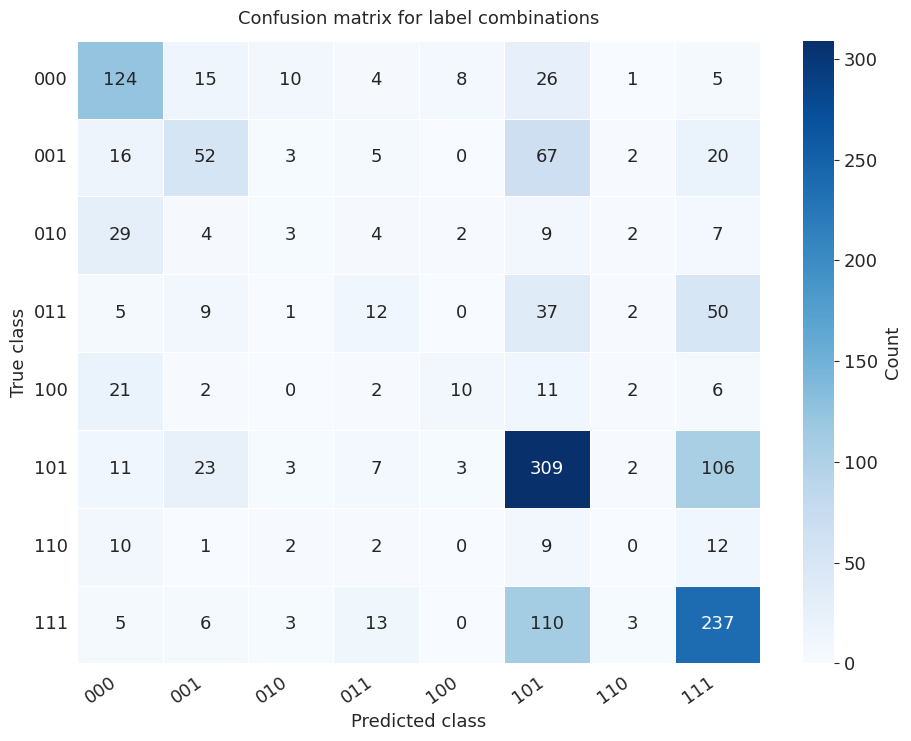

Selected configuration for error analysis:
  Variant: manual_selection
  Model family: gradient_boosting
  CV folds: 10
  Weighted F1: 0.4818
  Balanced accuracy: 0.3239


,class,support,support_pct,precision,recall,f1
0,000,193,13.17,0.5611,0.6425,0.5990
1,001,165,11.26,0.4643,0.3152,0.3755
2,010,60,4.10,0.1200,0.0500,0.0706
3,011,116,7.92,0.2449,0.1034,0.1455
4,100,54,3.69,0.4348,0.1852,0.2597
5,101,464,31.67,0.5346,0.6659,0.5931
6,110,36,2.46,0.0000,0.0000,0.0000
7,111,377,25.73,0.5350,0.6286,0.5780


,Binary label,Number of samples,Class share (%),F1-score,Balanced accuracy
0,101,464,31.67,0.5931,0.6659
1,111,377,25.73,0.5780,0.6286
2,000,193,13.17,0.5990,0.6425
3,001,165,11.26,0.3755,0.3152
4,011,116,7.92,0.1455,0.1034
5,010,60,4.10,0.0706,0.0500
6,100,54,3.69,0.2597,0.1852
7,110,36,2.46,0.0000,0.0000


,class,support,f1,recall,top_confused_with,confused_samples_to_top,confusion_rate_to_top_pct
0,110,36,0.0000,0.0000,111,12,33.33
1,010,60,0.0706,0.0500,000,29,48.33
2,011,116,0.1455,0.1034,111,50,43.10
3,100,54,0.2597,0.1852,000,21,38.89
4,001,165,0.3755,0.3152,101,67,40.61
5,111,377,0.5780,0.6286,101,110,29.18
6,101,464,0.5931,0.6659,111,106,22.84
7,000,193,0.5990,0.6425,101,26,13.47


In [18]:
# 1) Select the best (variant, model) from CV summary.
if refit_col not in cv_summary.columns:
    raise ValueError(f"Refit column not found in cv_summary: {refit_col}")

best_row = cv_summary.sort_values(refit_col, ascending=False).iloc[0]
error_variant = str(best_row["variant"])
error_model_family = ModelFamily(str(best_row["model_family"]))
error_best_params = json.loads(str(best_row["best_params_json"]))
error_cv_folds = int(run_config.get("cv_folds", settings.training_cv_folds))

# 2) Prepare matrices for this variant.
variant_data = load_variant_dataset(error_variant, data_dir="../data/processed")
matrices = prepare_training_matrices(
    variant_data.df,
    label_columns=settings.training_stratify_label_columns,
)
x_err = matrices.x.reset_index(drop=True)
y_err = matrices.y.astype(str).reset_index(drop=True)

# 3) Build model and generate out-of-fold predictions.
estimator_template = build_model_spec(
    error_model_family,
    n_features=x_err.shape[1],
).pipeline
estimator_template.set_params(**error_best_params)

fold_splits, _ = build_cv_splits(y_err, n_splits=error_cv_folds)

oof_pred = pd.Series(index=y_err.index, dtype=object, name="predicted_class")
for train_idx, test_idx in fold_splits:
    fold_estimator = clone(estimator_template)
    fold_estimator.fit(x_err.iloc[train_idx], y_err.iloc[train_idx])
    fold_predictions = fold_estimator.predict(x_err.iloc[test_idx])
    oof_pred.iloc[test_idx] = (
        pd.Series(fold_predictions, index=test_idx).astype(str).values
    )

if oof_pred.isna().any():
    raise ValueError("OOF prediction vector contains missing values.")

y_true = y_err.astype(str)
y_pred = oof_pred.astype(str)
class_labels = sorted(y_true.unique().tolist())

# 4) Compute per-class metrics and confusion matrix.
precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=class_labels,
    zero_division=0,
)

support_total = support.sum()
per_class_df = pd.DataFrame(
    {
        "class": class_labels,
        "support": support,
        "support_pct": 100 * support / support_total,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }
)
per_class_df["support_pct"] = per_class_df["support_pct"].round(2)
per_class_df[["precision", "recall", "f1"]] = per_class_df[
    ["precision", "recall", "f1"]
].round(4)

cm_counts = confusion_matrix(y_true, y_pred, labels=class_labels)
cm_counts_df = pd.DataFrame(cm_counts, index=class_labels, columns=class_labels)

row_totals = cm_counts.sum(axis=1, keepdims=True)
cm_norm = np.divide(
    cm_counts,
    row_totals,
    out=np.zeros_like(cm_counts, dtype=float),
    where=row_totals != 0,
)
cm_norm_df = pd.DataFrame(cm_norm, index=class_labels, columns=class_labels)

# 5) Build hardest-classes table.
hardest_rows = []
for idx, class_name in enumerate(class_labels):
    misclassified = cm_counts[idx].astype(int).copy()
    misclassified[idx] = 0

    if misclassified.sum() > 0:
        top_idx = int(np.argmax(misclassified))
        top_confused_with = class_labels[top_idx]
        top_confused_count = int(misclassified[top_idx])
    else:
        top_confused_with = None
        top_confused_count = 0

    class_support = int(support[idx])
    confusion_rate = (
        100 * top_confused_count / class_support if class_support > 0 else 0.0
    )
    hardest_rows.append(
        {
            "class": class_name,
            "support": class_support,
            "f1": float(f1[idx]),
            "recall": float(recall[idx]),
            "top_confused_with": top_confused_with,
            "confused_samples_to_top": top_confused_count,
            "confusion_rate_to_top_pct": confusion_rate,
        }
    )

hardest_df = pd.DataFrame(hardest_rows)
hardest_df["f1"] = hardest_df["f1"].round(4)
hardest_df["recall"] = hardest_df["recall"].round(4)
hardest_df["confusion_rate_to_top_pct"] = hardest_df["confusion_rate_to_top_pct"].round(
    2
)
hardest_df = hardest_df.sort_values(
    ["f1", "recall", "support"], ascending=[True, True, True]
).reset_index(drop=True)

# 6) Overall scores and class-combination summary.
oof_f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
oof_balanced_accuracy = balanced_accuracy_score(y_true, y_pred)

class_combination_summary_df = pd.DataFrame(
    {
        "class": class_labels,
        "count": support.astype(int),
        "percentage": 100.0 * support / support_total,
        "f1_score": f1,
        "balanced_acc": recall,
    }
)
class_combination_summary_df = class_combination_summary_df.sort_values(
    "count", ascending=False
).reset_index(drop=True)
class_combination_summary_df["percentage"] = class_combination_summary_df[
    "percentage"
].round(2)
class_combination_summary_df["f1_score"] = class_combination_summary_df[
    "f1_score"
].round(4)
class_combination_summary_df["balanced_acc"] = class_combination_summary_df[
    "balanced_acc"
].round(4)
class_combination_summary_df = class_combination_summary_df.rename(
    columns={
        "class": "Binary label",
        "count": "Number of samples",
        "percentage": "Class share (%)",
        "f1_score": "F1-score",
        "balanced_acc": "Balanced accuracy",
    }
)

# 7) Export tables and confusion matrix.
analysis_suffix = f"{analysis_version}_{error_variant}_{error_model_family.value}"
per_class_export = results_dir / f"per_class_metrics_{analysis_suffix}.csv"
class_combination_summary_export = (
    results_dir / f"class_combination_summary_{analysis_suffix}.csv"
)
hardest_export = results_dir / f"hardest_classes_{analysis_suffix}.csv"
cm_counts_export = results_dir / f"confusion_matrix_counts_{analysis_suffix}.csv"
cm_plot_export = results_dir / f"confusion_matrix_counts_{analysis_suffix}.pdf"
oof_pred_export = results_dir / f"oof_predictions_{analysis_suffix}.csv"

per_class_df.to_csv(per_class_export, index=False)
class_combination_summary_df.to_csv(class_combination_summary_export, index=False)
hardest_df.to_csv(hardest_export, index=False)
cm_counts_df.to_csv(cm_counts_export, index=True)

print(f"Saved: {per_class_export}")
print(f"Saved: {class_combination_summary_export}")
print(f"Saved: {hardest_export}")
print(f"Saved: {cm_counts_export}")

pd.DataFrame({"y_true": y_true, "y_pred": y_pred}).to_csv(oof_pred_export, index=False)
print(f"Saved: {oof_pred_export}")

# 8) Plot confusion matrix.
fig, ax = plt.subplots(
    figsize=(max(8.0, 1.2 * len(class_labels)), max(6.0, 0.95 * len(class_labels)))
)
sns.heatmap(
    cm_counts_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Count"},
    ax=ax,
)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Confusion matrix for label combinations", fontsize=13, pad=12)
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(cm_plot_export)
print(f"Saved: {cm_plot_export}")
plt.show()

print("Selected configuration for error analysis:")
print(f"  Variant: {error_variant}")
print(f"  Model family: {error_model_family.value}")
print(f"  CV folds: {error_cv_folds}")
print(f"  Weighted F1: {oof_f1_weighted:.4f}")
print(f"  Balanced accuracy: {oof_balanced_accuracy:.4f}")

display(per_class_df.sort_values("class").reset_index(drop=True))
display(class_combination_summary_df)
display(hardest_df.head(min(8, len(hardest_df))))

## 14. Two-run comparison
Compare either:
- the latest two runs (default), or
- two explicitly selected run IDs.

In [19]:
run_id_baselane: str | None = "20260411_102548"

In [20]:
run_dirs = sorted([p for p in training_root.iterdir() if p.is_dir()], reverse=True)
selected = selected_run_dir

if len(run_dirs) < 2:
    raise ValueError("Need at least two training runs for comparison.")

if run_id_baselane is None:
    selected_baselane = run_dirs[0] if run_dirs[0] != selected else run_dirs[1]
else:
    selected_baselane = training_root / run_id_baselane
    if not selected_baselane.exists() or not selected.exists():
        raise FileNotFoundError("One or both selected run IDs do not exist.")

if selected_baselane == selected:
    raise ValueError("Selected baseline and candidate runs are the same.")

print(f"Baseline run:  {selected_baselane.name}")
print(f"Candidate run: {selected.name}")

cv_a, cfg_a, refit_a, _ = load_training_run_artifacts(
    selected_baselane,
    fallback_refit_metric=settings.training_gridsearch_refit_metric,
)
cv_b, cfg_b, refit_b, _ = load_training_run_artifacts(
    selected,
    fallback_refit_metric=settings.training_gridsearch_refit_metric,
)

if refit_a != refit_b:
    raise ValueError(f"Refit metrics differ across runs: {refit_a} vs {refit_b}")

refit_metric = refit_a
refit_col = f"{refit_metric}_mean"
std_col = f"{refit_metric}_std"
comparison = cv_a[["variant", "model_family", refit_col, std_col]].merge(
    cv_b[["variant", "model_family", refit_col, std_col]],
    on=["variant", "model_family"],
    suffixes=("_a", "_b"),
    how="inner",
)
comparison["delta_mean"] = comparison[f"{refit_col}_b"] - comparison[f"{refit_col}_a"]
comparison["delta_std"] = comparison[f"{std_col}_b"] - comparison[f"{std_col}_a"]
comparison = comparison.sort_values(
    ["delta_mean", "variant"], ascending=[False, True]
).reset_index(drop=True)

comparison_display = format_mean_std_pairs(
    comparison,
    mean_cols=[f"{refit_col}_a", f"{refit_col}_b", "delta_mean"],
)
display(comparison_display)

comparison_export = (
    results_dir / f"run_comparison_{selected_baselane.name}_vs_{selected.name}.csv"
)
comparison.to_csv(comparison_export, index=False)
print(f"Saved: {comparison_export}")

comparison_heatmap_path = (
    results_dir
    / f"run_comparison_heatmap_{selected_baselane.name}_vs_{selected.name}.pdf"
)

heatmap_delta = comparison.pivot(
    index="variant", columns="model_family", values="delta_mean"
)
fig, ax = plt.subplots(figsize=(10, 4 + 0.6 * max(1, len(heatmap_delta))))
sns.heatmap(
    heatmap_delta,
    annot=True,
    fmt=".4f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": f"Δ {refit_metric} (candidate - baseline)"},
    ax=ax,
)
ax.set_title(
    f"Run comparison heatmap ({selected_baselane.name} vs {selected.name})",
    fontsize=13,
    pad=12,
)
ax.set_xlabel("Model family")
ax.set_ylabel("Variant")
plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(comparison_heatmap_path)
plt.show()
print(f"Saved: {comparison_heatmap_path}")

Baseline run:  20260411_102548
Candidate run: 20260413_155156


ValueError: Refit metrics differ across runs: f1_macro vs f1_weighted